In [14]:
# === Cell 1: Setup & activate last run ===

import importlib
import numpy as np

import infra
import embeddings

importlib.reload(infra)
importlib.reload(embeddings)

# Activate last run explicitly (strict: errors if none)
infra.activate_last_run(echo=False)

# Load config + encoder spec for the active run (does not create a new run)
RP, cfg, ENCODER_SPEC = infra.load_embeddings_run(strict=True)

# Reproducibility (one place only)
SEED = 42
np.random.seed(SEED)

# Read run parameters from config (single source of truth)
YEAR = int(cfg.get("year", 2025))
ONET_VERSION = str(cfg.get("onet_version", "30_0"))
ENCODER_NAME = str(cfg.get("encoder_name", "")).strip()

print("PROJECT_ROOT :", infra.PROJECT_ROOT)
print("RUNS_ROOT    :", infra.RUNS_ROOT)
print("RUN_TAG      :", infra.RUN_TAG)
print("RUN_DIR      :", infra.RUN_DIR)
print("Exports      :", RP.exports)
print("Cache (run)  :", RP.cache)
print("Cache (glob) :", infra.GLOBAL_CACHE_ROOT)
print("YEAR         :", YEAR)
print("ONET_VERSION :", ONET_VERSION)
print("ENCODER_NAME :", ENCODER_NAME)
print("ENCODER_ID   :", ENCODER_SPEC.embedder_id())
print("SEED         :", SEED)


PROJECT_ROOT : /home/joc/code/geometry-of-work
RUNS_ROOT    : /home/joc/code/geometry-of-work/out/runs
RUN_TAG      : embeddings__openai__text-embedding-3-large__d3072__year-2025__v30_1
RUN_DIR      : /home/joc/code/geometry-of-work/out/runs/embeddings__openai__text-embedding-3-large__d3072__year-2025__v30_1
Exports      : /home/joc/code/geometry-of-work/out/runs/embeddings__openai__text-embedding-3-large__d3072__year-2025__v30_1/exports
Cache (run)  : /home/joc/code/geometry-of-work/out/runs/embeddings__openai__text-embedding-3-large__d3072__year-2025__v30_1/cache
Cache (glob) : /home/joc/code/geometry-of-work/out/_cache
YEAR         : 2025
ONET_VERSION : 30_1
ENCODER_NAME : openai-3-large
ENCODER_ID   : openai:text-embedding-3-large?dim=3072
SEED         : 42


In [15]:
# === Cell 2: Imports ===

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

from matplotlib.colors import LinearSegmentedColormap, Normalize, to_rgba

In [16]:
# === Cell 3: Label adjustment ===

try:
    from adjustText import adjust_text
except ImportError:
    adjust_text = None

In [17]:
# === Cell 4: Plot helpers ===

def to_cartesian(df, angle_col, radius_col, x_col="x_cart", y_col="y_cart"):
    df = df.copy()
    ang = df[angle_col].to_numpy()
    r = df[radius_col].to_numpy()
    df[x_col] = r * np.cos(ang)
    df[y_col] = r * np.sin(ang)
    return df


def add_polar_frame(
    ax,
    radii=(0.2, 0.4, 0.6, 0.8, 1.0),
    circle_color="#333333",
    circle_lw=0.3,
    outer_lw=0.5,
    spoke_color="#333333",
    spoke_lw=0.4,
    label_color="#333333",
    label_fs=9,
    label_r=1.06,
    degree_labels=("0°", "45°", "90°", "135°", "180°", "225°", "270°", "315°"),
    cross_color="#B3B3B3",
    cross_lw=0.3,
    draw_labels=True,
    draw_spokes=True,
    draw_cross=True,
):
    theta = np.linspace(0, 2 * np.pi, 400)

    for r in radii:
        lw = outer_lw if np.isclose(r, max(radii)) else circle_lw
        ax.plot(r * np.cos(theta), r * np.sin(theta), color=circle_color, lw=lw, zorder=1)

    angles = np.arange(0, 2 * np.pi, np.pi / 4)

    if draw_spokes:
        for a in angles:
            ax.plot([0, np.cos(a)], [0, np.sin(a)], color=spoke_color, lw=spoke_lw, zorder=1)

    if draw_labels:
        for a, lab in zip(angles, degree_labels):
            ax.text(
                label_r * np.cos(a),
                label_r * np.sin(a),
                lab,
                ha="center",
                va="center",
                fontsize=label_fs,
                color=label_color,
                zorder=2,
            )

    if draw_cross:
        ax.plot([-1, 1], [0, 0], color=cross_color, lw=cross_lw, zorder=1)
        ax.plot([0, 0], [-1, 1], color=cross_color, lw=cross_lw, zorder=1)


def rt_bin_cut(rt):
    bins = [-np.inf, 50, 60, 70, 80, 90, np.inf]
    labels = ["<50", "50–59", "60–69", "70–79", "80–89", "90+"]
    return pd.cut(rt, bins=bins, labels=labels, right=False, include_lowest=True)


def warm_to_base_cmap(base_hex, warm_hex="#F4F1EC", name="warm_to_base"):
    return LinearSegmentedColormap.from_list(name, [warm_hex, base_hex])


def make_job_family_colors(categories, palette_hex):
    cats = list(pd.unique(categories))
    pal = list(palette_hex)
    if len(cats) > len(pal):
        reps = int(np.ceil(len(cats) / len(pal)))
        pal = (pal * reps)[: len(cats)]
    return dict(zip(cats, pal))


def labels_with_leaders(
    ax,
    x,
    y,
    labels,
    nudge_x,
    nudge_y,
    fontsize=12,
    text_color="black",
    line_color="#B3B3B3",
    line_lw=0.8,
    end_pad=0.03,
):
    x = np.asarray(x)
    y = np.asarray(y)
    nudge_x = np.asarray(nudge_x)
    nudge_y = np.asarray(nudge_y)

    x_end = x + nudge_x
    y_end = y + nudge_y

    # Leader lines
    ax.plot(
        np.column_stack([x, x_end]).T,
        np.column_stack([y, y_end]).T,
        color=line_color,
        linewidth=line_lw,
        zorder=4,
    )

    # Push label a bit further in the same direction
    vx = x_end - x
    vy = y_end - y
    vlen = np.hypot(vx, vy)
    ux = np.where(vlen > 0, vx / vlen, 0.0)
    uy = np.where(vlen > 0, vy / vlen, 0.0)

    x_text = x_end + end_pad * ux
    y_text = y_end + end_pad * uy

    for xi, yi, lab, dx in zip(x_text, y_text, labels, ux):
        ha = "left" if dx >= 0 else "right"
        ax.text(
            xi,
            yi,
            lab,
            fontsize=fontsize,
            color=text_color,
            ha=ha,
            va="center",
            zorder=5,
        )


def minimal_axes(ax):
    ax.set_xticks([])
    ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_visible(False)


def polar_inset(ax, df, occ_title, base_col, pad=0.08, max_m=1.3):
    df_occ = df[df["Title"] == occ_title].copy()
    if df_occ.empty:
        ax.set_axis_off()
        return

    # White frame inside inset
    add_polar_frame(
        ax,
        circle_color="white",
        spoke_color="white",
        cross_color=GG_GREY["grey50"],
        draw_labels=False,
    )

    # Warm-white to occupation color
    cmap = LinearSegmentedColormap.from_list("warm_to_base", ["#F4F1EC", base_col])

    v = df_occ["rt_strength"].to_numpy(dtype=float)
    vmin = np.nanmin(v)
    vmax = np.nanmax(v)

    if not np.isfinite(vmin) or not np.isfinite(vmax) or vmin == vmax:
        colors = base_col
    else:
        norm = Normalize(vmin=vmin, vmax=vmax)
        colors = cmap(norm(v))

    ax.scatter(
        df_occ["x_cart"],
        df_occ["y_cart"],
        s=30,
        c=colors,
        edgecolors="none",
        zorder=3,
    )

    # Symmetric limits
    m = np.nanmax(np.abs(df_occ[["x_cart", "y_cart"]].to_numpy()))
    m = float(m) if np.isfinite(m) else 1.0
    m = min(max_m, m + pad)

    ax.set_xlim(-m, m)
    ax.set_ylim(-m, m)
    ax.set_aspect("equal", adjustable="box")
    ax.set_title(occ_title, fontsize=12, pad=2)
    minimal_axes(ax)

In [18]:
# === Cell 5: Palette ===
# Palette nature23 and job-family color mapping
nature23 = [
    "#1B4F72", "#2874A6", "#5499C7", "#7FB3D5",
    "#6C3483", "#8E44AD", "#AF7AC5",
    "#7D6608", "#B7950B", "#D4AC0D",
    "#7E5109", "#A04000", "#CA6F1E",
    "#7B241C", "#922B21", "#CD6155",
    "#145A32", "#1E8449", "#52BE80",
    "#424949", "#616A6B", "#85929E",
]
GG_GREY = {
    "grey20": "0.2",
    "grey50": "0.5",
    "grey60": "0.6",
    "grey70": "0.7",
    "grey90": "0.9",
    "white":  "1.0",
    "black":  "0.0"
}

In [19]:
# === Cell 6: Read inputs from the active run ===

print("Using exports:", RP.exports)

shock_fp = RP.export_fp("task_embeddings_polar_scaled.csv")
jobs_fp  = RP.export_fp("occupation_embeddings_polar_scaled.csv")

shock = infra.read_csv_any(shock_fp)
jobs  = infra.read_csv_any(jobs_fp)

print("Loaded:", shock_fp.name, shock.shape)
print("Loaded:", jobs_fp.name, jobs.shape)

Using exports: /home/joc/code/geometry-of-work/out/runs/embeddings__openai__text-embedding-3-large__d3072__year-2025__v30_1/exports
Loaded: task_embeddings_polar_scaled.csv (17606, 17)
Loaded: occupation_embeddings_polar_scaled.csv (878, 13)


In [20]:
# === Cell 7: Build job-family color map ===

# Drop missing job families for color robustness
jobs_for_colors = jobs.dropna(subset=["Job Family"]).copy()

# Build colors on cleaned categories
jobfam_colmap = make_job_family_colors(jobs_for_colors["Job Family"], nature23)

# Extra safety
jobfam_colmap = {k: v for k, v in jobfam_colmap.items() if pd.notna(k)}

In [21]:
# === Cell 8: Task relevance bins ===

shock = shock.copy()

shock["rt_bin"] = pd.cut(
    shock["rt"],
    bins=[-np.inf, 50, 60, 70, 80, 90, np.inf],
    labels=["<50", "50–59", "60–69", "70–79", "80–89", "90+"],
    right=False,
    include_lowest=True,
)

# Numeric strength 1..6
shock["rt_strength"] = shock["rt_bin"].cat.codes + 1
shock.loc[shock["rt_bin"].isna(), "rt_strength"] = np.nan

In [22]:
# === Cell 9: Cartesian coordinates ===

# Tasks: angle=xi, radius=chi
shock = to_cartesian(shock, angle_col="xi", radius_col="chi")

# Occupations: angle=xi, radius=chi
jobs = to_cartesian(jobs, angle_col="xi", radius_col="chi")

In [23]:
# === Cell 10: Selected occupation labels ===

jobs_lab = jobs.copy()

label_map = {
    "Software Developers": "Software Developer",
    "Biological Science Teachers, Postsecondary": "Biology Teacher",
    "Lawyers": "Lawyer",
    "Dishwashers": "Dishwasher",
    "Carpenters": "Carpenter",
}

jobs_lab["occ"] = jobs_lab["Title"].map(label_map)
jobs_lab = jobs_lab.dropna(subset=["occ"]).copy()

# Manual nudges
jobs_lab["nudge_x"] = 0.0
jobs_lab.loc[jobs_lab["occ"] == "Biology Teacher",    "nudge_x"] =  0.20
jobs_lab.loc[jobs_lab["occ"] == "Software Developer", "nudge_x"] =  0.10
jobs_lab.loc[jobs_lab["occ"] == "Lawyer",             "nudge_x"] =  0.30
jobs_lab.loc[jobs_lab["occ"] == "Dishwasher",         "nudge_x"] = -0.15
jobs_lab.loc[jobs_lab["occ"] == "Carpenter",          "nudge_x"] = -0.30

jobs_lab["nudge_y"] = 0.0
jobs_lab.loc[jobs_lab["occ"] == "Biology Teacher",    "nudge_y"] = -0.20
jobs_lab.loc[jobs_lab["occ"] == "Software Developer", "nudge_y"] =  0.20
jobs_lab.loc[jobs_lab["occ"] == "Lawyer",             "nudge_y"] =  0.10
jobs_lab.loc[jobs_lab["occ"] == "Dishwasher",         "nudge_y"] = -0.20
jobs_lab.loc[jobs_lab["occ"] == "Carpenter",          "nudge_y"] = -0.10

In [24]:
# === Cell 11: Recode selected task titles ===

shock["rt_bin"] = rt_bin_cut(shock["rt"])

shock["Title"] = shock["Title"].replace({
    "Waiters and Waitresses": "Waiter",
    "Physicians, Pathologists": "Pathologist",
    "Machinists": "Machinist",
    "Chemical Engineers": "Chemical Engineer",
})

In [25]:
# === Cell 12: Colors for inset occupations ===

occ_titles = ["Waiter", "Pathologist", "Machinist", "Chemical Engineer"]

title_to_jobs_title = {
    "Waiter": "Waiters and Waitresses",
    "Pathologist": "Physicians, Pathologists",
    "Machinist": "Machinists",
    "Chemical Engineer": "Chemical Engineers",
}

def mainplot_color_for_title(jobs_df, jobs_title, jobfam_colmap):
    sub = jobs_df.loc[jobs_df["Title"] == jobs_title, "Job Family"].dropna()
    if sub.empty:
        return None, None
    jf = sub.value_counts().idxmax()
    return jf, jobfam_colmap.get(jf)

cols = {}
for occ in occ_titles:
    jobs_title = title_to_jobs_title[occ]
    jf, col = mainplot_color_for_title(jobs, jobs_title, jobfam_colmap)
    if col is None:
        raise ValueError(f"Could not find Job Family/color for {occ} ({jobs_title}).")
    cols[occ] = col
    print(f"{occ:17s} | jobs title = {jobs_title:35s} | Job Family = {jf} | color = {col}")

Waiter            | jobs title = Waiters and Waitresses              | Job Family = Food Preparation and Serving Related | color = #CA6F1E
Pathologist       | jobs title = Physicians, Pathologists            | Job Family = Healthcare Practitioners and Technical | color = #D4AC0D
Machinist         | jobs title = Machinists                          | Job Family = Production | color = #616A6B
Chemical Engineer | jobs title = Chemical Engineers                  | Job Family = Architecture and Engineering | color = #7FB3D5


Saved: /home/joc/code/geometry-of-work/out/runs/embeddings__openai__text-embedding-3-large__d3072__year-2025__v30_1/figures/Figure3_division_of_labor.pdf


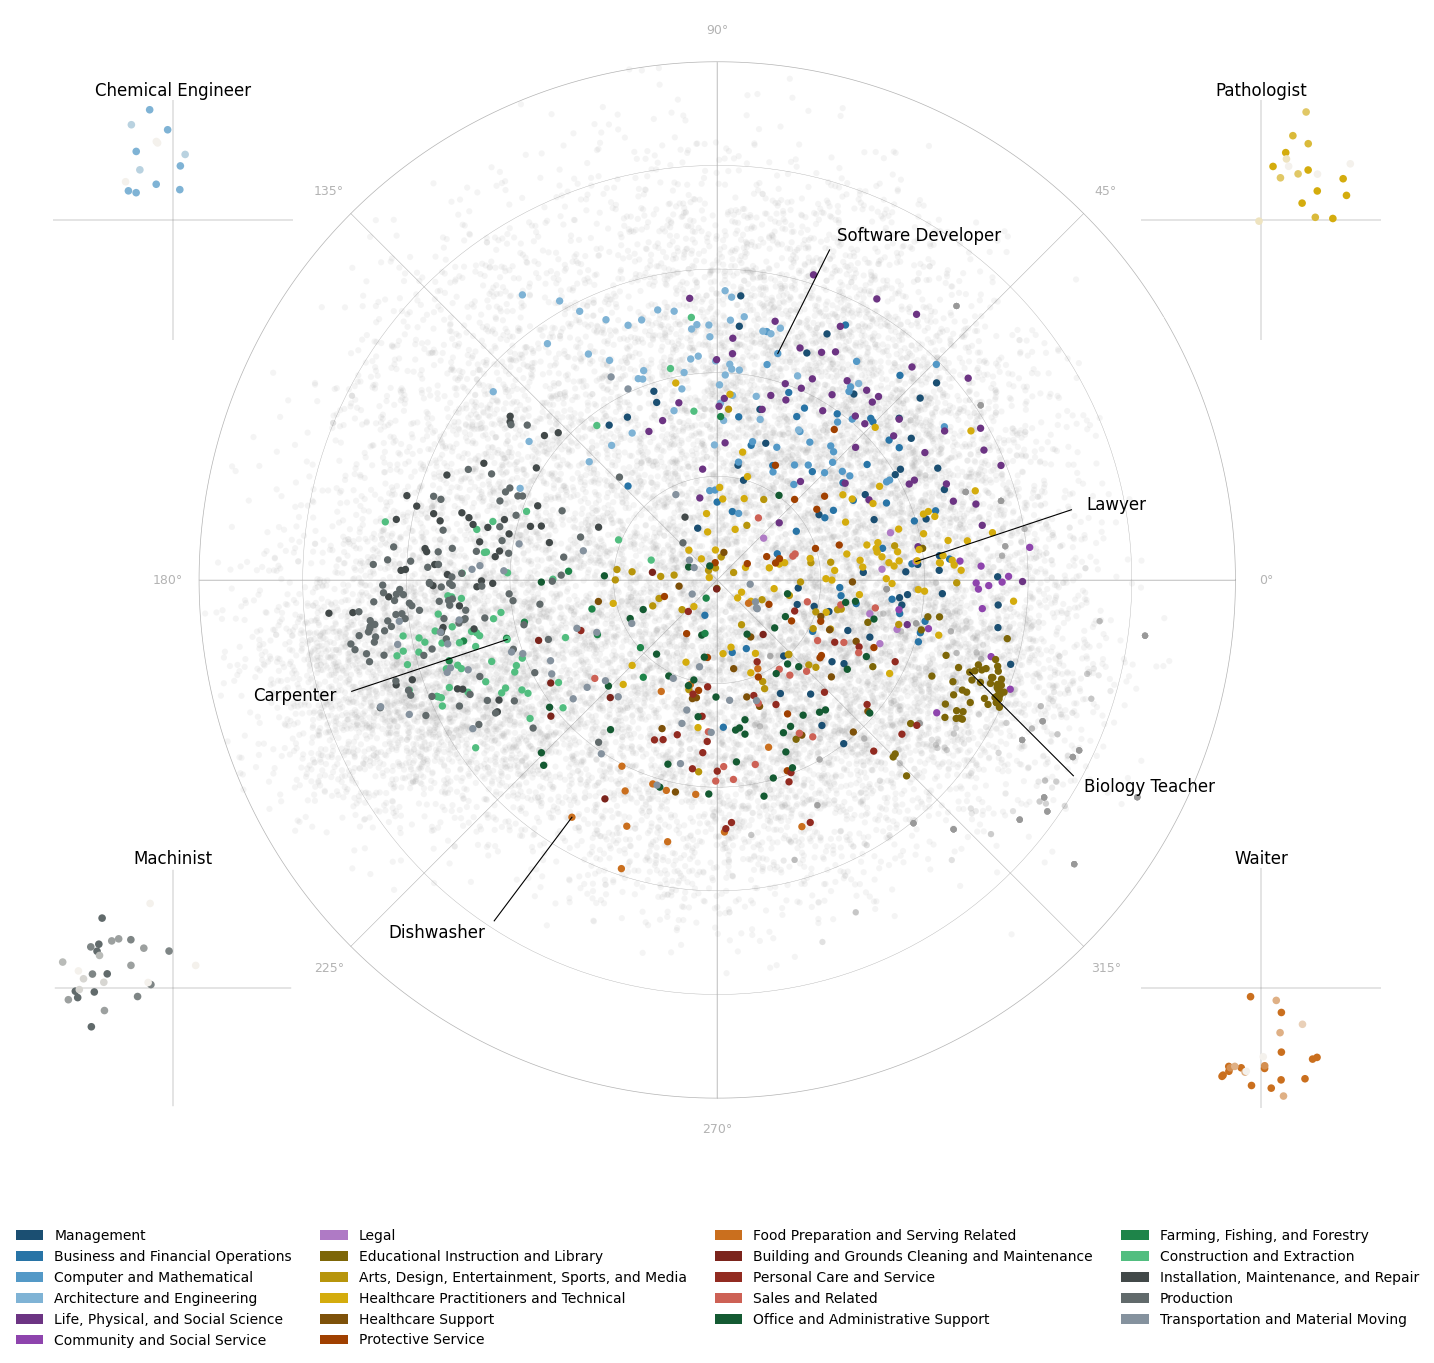

In [26]:
# === Cell 13: Main figure ===

plt.close("all")

# Layout in figure coordinates
MAIN_W, MAIN_H = 0.95, 0.95
MAIN_CX, MAIN_CY = 0.5, 0.5

MAIN = dict(
    left=MAIN_CX - MAIN_W / 2,
    bottom=MAIN_CY - MAIN_H / 2,
    width=MAIN_W,
    height=MAIN_H,
)

SMALL_W = 0.20
SMALL_H = 0.20
M = 0.06

CE   = dict(left=M,               bottom=0.70, width=SMALL_W, height=SMALL_H)
PHYS = dict(left=1 - M - SMALL_W, bottom=0.70, width=SMALL_W, height=SMALL_H)
MACH = dict(left=M,               bottom=0.06, width=SMALL_W, height=SMALL_H)
WAIT = dict(left=1 - M - SMALL_W, bottom=0.06, width=SMALL_W, height=SMALL_H)

fig = plt.figure(figsize=(16, 12))
fig.patch.set_facecolor("white")

ax_main = fig.add_axes([MAIN["left"], MAIN["bottom"], MAIN["width"], MAIN["height"]])
ax_ce   = fig.add_axes([CE["left"],   CE["bottom"],   CE["width"],   CE["height"]])
ax_phys = fig.add_axes([PHYS["left"], PHYS["bottom"], PHYS["width"], PHYS["height"]])
ax_mach = fig.add_axes([MACH["left"], MACH["bottom"], MACH["width"], MACH["height"]])
ax_wait = fig.add_axes([WAIT["left"], WAIT["bottom"], WAIT["width"], WAIT["height"]])

for ax in [ax_main, ax_ce, ax_phys, ax_mach, ax_wait]:
    ax.patch.set_alpha(0)
    ax.set_facecolor("none")
    minimal_axes(ax)

# Main polar frame
add_polar_frame(
    ax_main,
    circle_color=GG_GREY["grey70"],
    spoke_color=GG_GREY["grey70"],
    label_color=GG_GREY["grey70"],
    cross_color=GG_GREY["grey70"],
    draw_labels=True,
    label_fs=9,
    label_r=1.06,
)

# Background tasks
ax_main.scatter(
    shock["x_cart"],
    shock["y_cart"],
    s=20,
    alpha=0.10,
    c=GG_GREY["grey60"],
    edgecolors="none",
)

# Occupations by job family
job_colors = jobs["Job Family"].map(jobfam_colmap)
mask = job_colors.notna()

ax_main.scatter(
    jobs.loc[mask, "x_cart"],
    jobs.loc[mask, "y_cart"],
    s=28,
    c=job_colors.loc[mask].values,
    edgecolors="none",
    zorder=3,
)

# Labels with leader lines
labels_with_leaders(
    ax_main,
    jobs_lab["x_cart"].to_numpy(),
    jobs_lab["y_cart"].to_numpy(),
    jobs_lab["occ"].tolist(),
    jobs_lab["nudge_x"].to_numpy(),
    jobs_lab["nudge_y"].to_numpy(),
    fontsize=12,
    line_color=GG_GREY["black"],
)

ax_main.set_aspect("equal", adjustable="box")
ax_main.set_xlim(-1.1, 1.1)
ax_main.set_ylim(-1.1, 1.1)

# Insets
polar_inset(ax_phys, shock, "Pathologist",       cols["Pathologist"])
polar_inset(ax_wait, shock, "Waiter",            cols["Waiter"])
polar_inset(ax_mach, shock, "Machinist",         cols["Machinist"])
polar_inset(ax_ce,   shock, "Chemical Engineer", cols["Chemical Engineer"])

# Figure-level legend
handles = [
    mpatches.Patch(facecolor=color, edgecolor="none", label=jobfam)
    for jobfam, color in jobfam_colmap.items()
]

fig.legend(
    handles=handles,
    loc="lower center",
    ncol=4,
    frameon=False,
    fontsize=10,
    bbox_to_anchor=(0.5, -0.15),
)

# Save via infra run paths
out_pdf = RP.figure_fp("Figure3_division_of_labor.pdf")
fig.savefig(out_pdf, dpi=600, bbox_inches="tight", facecolor="white")

print("Saved:", out_pdf)

plt.show()